[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


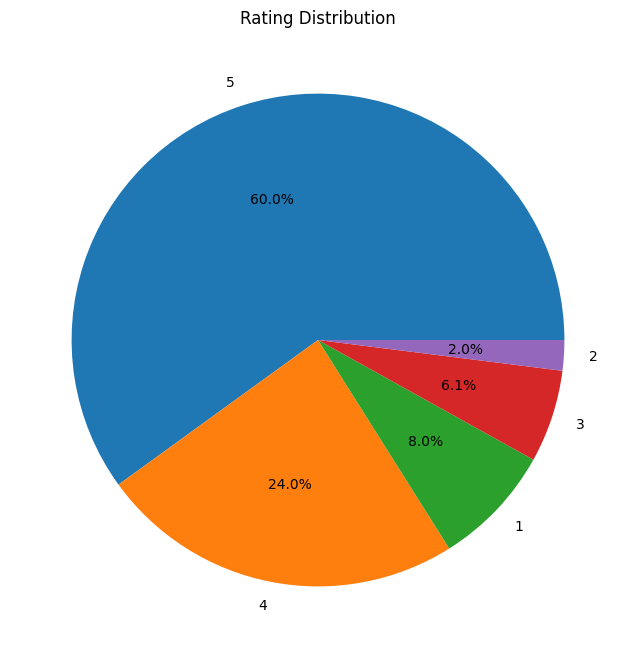


Ratings Count:
Rating
5    1382
4     552
1     184
3     140
2      46
Name: count, dtype: int64


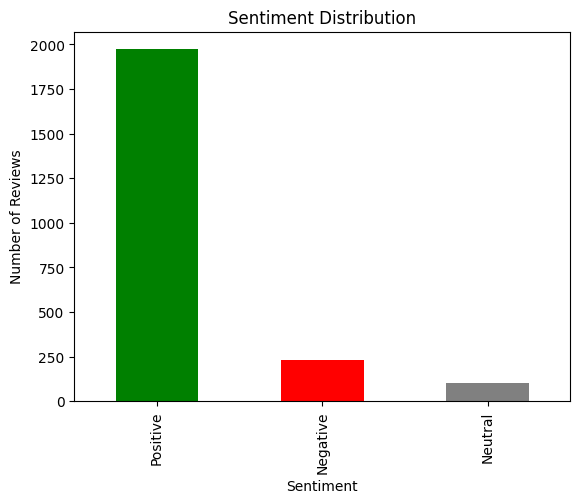


Sentiment Count:
Sentiment
Positive    1973
Negative     229
Neutral      102
Name: count, dtype: int64

Total Sentiment Scores:
Sum of Positive Sentiment: 835.67
Sum of Negative Sentiment: 104.92
Sum of Neutral Sentiment : 1363.41

Enter a Flipkart review to analyze: the shoe are stylish and comfortable, it is nice product

Sentiment Analysis Results:
Positive: 0.433
Negative: 0.0
Neutral : 0.567
Compound: 0.7269
Overall Sentiment: Positive


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Download VADER lexicon if not already present
nltk.download('vader_lexicon')

# Initialize Sentiment Analyzer
sid = SentimentIntensityAnalyzer()

# Function to load and clean the dataset
def load_and_clean_data(path):
    df = pd.read_csv(path)
    cleaned_df = df.dropna()
    return cleaned_df

# Function to plot the rating distribution
def plot_rating_distribution(df):
    ratings = df['Rating'].value_counts()
    numbers = ratings.index
    quantity = ratings.values

    plt.figure(figsize=(10, 8))
    plt.pie(quantity, labels=numbers, autopct='%1.1f%%')
    plt.title("Rating Distribution")
    plt.show()

    print("\nRatings Count:")
    print(ratings)

# Function to perform sentiment analysis on all reviews
def analyze_sentiments(df):
    data = pd.DataFrame(df['Review'])

    # Add sentiment scores
    data['Positive'] = data['Review'].apply(lambda x: sid.polarity_scores(x)['pos'])
    data['Negative'] = data['Review'].apply(lambda x: sid.polarity_scores(x)['neg'])
    data['Neutral']  = data['Review'].apply(lambda x: sid.polarity_scores(x)['neu'])
    data['Compound'] = data['Review'].apply(lambda x: sid.polarity_scores(x)['compound'])

    # Label overall sentiment based on compound score
    def get_sentiment(score):
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

    data['Sentiment'] = data['Compound'].apply(get_sentiment)

    return data

# Function to plot overall sentiment distribution
def plot_sentiment_distribution(data):
    sentiment_counts = data['Sentiment'].value_counts()
    sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
    plt.title('Sentiment Distribution')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()

    print("\nSentiment Count:")
    print(sentiment_counts)

# Function to calculate total sentiment scores
def show_sentiment_totals(data):
    print("\nTotal Sentiment Scores:")
    print("Sum of Positive Sentiment:", round(data['Positive'].sum(), 2))
    print("Sum of Negative Sentiment:", round(data['Negative'].sum(), 2))
    print("Sum of Neutral Sentiment :", round(data['Neutral'].sum(), 2))

# Function to analyze a user-provided review
def analyze_single_review():
    user_review = input("\nEnter a Flipkart review to analyze: ")
    score = sid.polarity_scores(user_review)

    print("\nSentiment Analysis Results:")
    print(f"Positive: {score['pos']}")
    print(f"Negative: {score['neg']}")
    print(f"Neutral : {score['neu']}")
    print(f"Compound: {score['compound']}")

    if score['compound'] >= 0.05:
        print("Overall Sentiment: Positive")
    elif score['compound'] <= -0.05:
        print("Overall Sentiment: Negative")
    else:
        print("Overall Sentiment: Neutral")

# Main execution
if __name__ == "__main__":
    # Load and clean the data
    df = load_and_clean_data('/content/drive/MyDrive/flipkart.csv')

    # Plot rating distribution
    plot_rating_distribution(df)

    # Analyze sentiments in dataset
    analyzed_data = analyze_sentiments(df)

    # Show sentiment distribution chart
    plot_sentiment_distribution(analyzed_data)

    # Show sum of sentiment scores
    show_sentiment_totals(analyzed_data)

    # Analyze a single user-input review
    analyze_single_review()